In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

In [2]:
### do the same but with productivity estimates
## read in TSD model estimations
all_rates=pd.read_pickle('../data/final_rates_v1_2µm.pickle')
all_tsd=pd.read_pickle('../data/all_seaflow_tsd_mixed_v1_2µm.pickle')
mean_tsd=all_tsd.groupby(['cruise','cruise_day','pop'])[['lat','lon','pop']].mean().reset_index()
## do some cleaning
good_rates=all_rates.merge(mean_tsd)
# bin lat values and remove bad productivity values
good_rates['round_lat']=0.5 * round(good_rates['lat']/0.5)
good_rates=good_rates.loc[good_rates['productivity']<20]
good_rates['time'] = pd.to_datetime(good_rates['time'])

### G3 (2019) size fractionated data
- Collected by Karin Björkman

In [3]:
# inputs: TSD dataframe, SF dataframe (14C), cruise = str representing cruise name
# outputs: merged file with pooled standard errors
def calc_pooled_errs(df_TSD, df_sf, cruise):
    # calculate std from se using n (daylength)
    df_TSD['productivity_std'] = df_TSD['productivity_se'] * np.sqrt(df_TSD['daylength'])
    # calculate variance from std 
    df_TSD['productivity_var'] = df_TSD['productivity_std'] ** 2

    # calculate total pico productivity (with syn for G3)
    TSD_total = df_TSD.copy()
    # convert fromg long to wide
    TSD_total['round_lat'] = 2 * round(TSD_total['lat'] / 2)
    df_TSD_wide=TSD_total[['time', 'pop', 'productivity', 'productivity_var', 'daylength', 'round_lat']].pivot(index=['time', 'daylength', 'round_lat'], columns='pop')
    df_TSD_wide.columns=['_'.join(col).strip() for col in df_TSD_wide.columns.values]
    df_TSD_wide.reset_index(inplace=True)
    if cruise == 'G3':
        df_TSD_total = df_TSD_wide.loc[(df_TSD_wide['productivity_picoeuk'].notnull()) & (df_TSD_wide['productivity_prochloro'].notnull())  & (df_TSD_wide['productivity_synecho'].notnull())]
        df_TSD_total['productivity_mean_total'] = df_TSD_total['productivity_picoeuk'] + df_TSD_total['productivity_prochloro'] + df_TSD_total['productivity_synecho']
        # calculate std from variance
        df_TSD_total['productivity_std_total'] = np.sqrt(np.nansum([df_TSD_total['productivity_var_picoeuk'], df_TSD_total['productivity_var_prochloro'] + df_TSD_total['productivity_var_synecho']], axis = 0))
    else:
        # exclude syn for G4-5
        df_TSD_total = df_TSD_wide.loc[(df_TSD_wide['productivity_picoeuk'].notnull()) & (df_TSD_wide['productivity_prochloro'].notnull())]
        df_TSD_total['productivity_mean_total'] = df_TSD_total['productivity_picoeuk'] + df_TSD_total['productivity_prochloro']
        # calculate std from variance
        df_TSD_total['productivity_std_total'] = np.sqrt(np.nansum([df_TSD_total['productivity_var_picoeuk'], df_TSD_total['productivity_var_prochloro']], axis = 0))
    # calculate se from std
    df_TSD_total['productivity_se_total'] = df_TSD_total['productivity_std_total'] / np.sqrt(df_TSD_total['daylength'] * 3)
    # merge with 14C sf data
    df_TSD_total['time'] = pd.to_datetime(df_TSD_total['time'])
    df_sf['time'] = pd.to_datetime(df_sf['time'])
    df_merged = df_TSD_total[['time', 'productivity_mean_total', 'productivity_se_total']].merge(df_sf)
    df_merged['cruise'] = cruise
    return df_TSD_total, df_merged

In [4]:
## add in g3 size fractionated data
g3_sf = pd.read_csv('../data/g3_sf.csv')
# bin by 2 degrees
reps = 2 # 2 replicates
g3_sf['se'] = g3_sf['stdev.3'] / np.sqrt(2)
# calculate means and pooled standard deviations (assumign triplicates)

## merge with g3 data
g3_TSD = good_rates.loc[good_rates['cruise'] == 'KM1906']
## calculate variance from standard error 
## get n (number of hours per day)- calculate from daylength
dl_df = all_tsd.groupby(['cruise', 'cruise_day'])['daylength'].mean().reset_index()
g3_TSD = g3_TSD.merge(dl_df)
g3_tsd_total, g3_pooled = calc_pooled_errs(g3_TSD, g3_sf, 'G3')

### Are Synechococcus populations a big part of small phytoplankton TSD-PP?
How much does Syn contribute to picoplankton PP?
- up to 50% at 34ºN!

In [5]:
# filter days where all pops are present
day_population_counts = g3_TSD.groupby('cruise_day')['pop'].nunique()
days_with_all = day_population_counts[day_population_counts == 3].index
filtered_df = g3_TSD[g3_TSD['cruise_day'].isin(days_with_all)]

# sum total productivity
total_prod = filtered_df.groupby(['time', 'cruise_day'])['productivity'].transform('sum')
# calculate the total percent 
filtered_df['percent'] = 100 * filtered_df['productivity'] / total_prod
# check each population
g3_percents = filtered_df.groupby(['time', 'cruise_day', 'pop']).sum().reset_index()
# just get pro percentages
g3_pro = g3_percents.loc[g3_percents['pop'] == 'prochloro']
g3_merged = g3_pooled.merge(g3_pro[['time', 'cruise_day', 'biomass', 'productivity', 'percent']])

### G4-5 (2021, 2023)
- exclude Syn, only up to 3% of total picoplantkon NPP
- 14C measurements collected by Angel White

In [6]:
# G4 SF data
g4_sf=pd.read_csv('../data/G4_sf.csv')
g4_sf['round_lat'] = 2 * round(g4_sf['Latitude'] / 2)
g4_sf['se'] = g4_sf['stdev.3'] / np.sqrt(2)
g4_sf_subset = g4_sf[['time', '0.2-2.0 mm', 'se']]
# merge
g4_sf_subset['time'] = pd.to_datetime(g4_sf_subset['time'])
## merge with g4 TSD data
g4_TSD = good_rates.loc[good_rates['cruise'] == 'TN397']
## calculate variance from standard error 
## get n (number of hours per day)- calculate from daylength
dl_df = all_tsd.groupby(['cruise', 'cruise_day'])['daylength'].mean().reset_index()
g4_TSD = g4_TSD.merge(dl_df)
g4_tsd_total, g4_pooled = calc_pooled_errs(g4_TSD, g4_sf, 'G4')

# G5 SF data
g5_sf=pd.read_csv('../data/G5_14C_init_summary.csv')
g5_sf['se'] = g5_sf['stdev.3'] / np.sqrt(2)
g5_sf_subset = g5_sf[['time', '0.2-2.0 mm', 'se']]
g5_sf_subset['time'] = pd.to_datetime(g5_sf_subset['time'])
## merge with g5 TSD data
g5_TSD = good_rates.loc[good_rates['cruise'] == 'TN412']
## calculate variance from standard error 
## get n (number of hours per day)- calculate from daylength
dl_df = all_tsd.groupby(['cruise', 'cruise_day'])['daylength'].mean().reset_index()
g5_TSD = g5_TSD.merge(dl_df)
g5_tsd_total, g5_pooled = calc_pooled_errs(g5_TSD, g5_sf, 'G5')

In [7]:
# filter days only pro and picoeuks are present
day_population_counts = g4_TSD.loc[g4_TSD['pop'] != 'synecho'].groupby('cruise_day')['pop'].nunique()
days_with_all = day_population_counts[day_population_counts == 2].index
filtered_df = g4_TSD[g4_TSD['cruise_day'].isin(days_with_all)]

# sum total productivity
total_prod = filtered_df.groupby(['time', 'cruise_day'])['productivity'].transform('sum')
# calculate the total percent 
filtered_df['percent'] = 100 * filtered_df['productivity'] / total_prod
# check each population
g4_percents = filtered_df.groupby(['time', 'cruise_day', 'pop']).sum().reset_index()
# just get pro percentages
g4_pro = g4_percents.loc[g4_percents['pop'] == 'prochloro']
g4_merged = g4_pooled.merge(g4_pro[['time', 'cruise_day', 'biomass', 'productivity', 'percent']])

# filter days only pro and picoeuks are present
day_population_counts = g5_TSD.loc[g5_TSD['pop'] != 'synecho'].groupby('cruise_day')['pop'].nunique()
days_with_all = day_population_counts[day_population_counts == 2].index
filtered_df = g5_TSD[g5_TSD['cruise_day'].isin(days_with_all)]

# sum total productivity
total_prod = filtered_df.groupby(['time', 'cruise_day'])['productivity'].transform('sum')
# calculate the total percent 
filtered_df['percent'] = 100 * filtered_df['productivity'] / total_prod
# check each population
g5_percents = filtered_df.groupby(['time', 'cruise_day', 'pop']).sum().reset_index()
# just get pro percentages
g5_pro = g5_percents.loc[g5_percents['pop'] == 'prochloro']
g5_merged = g5_pooled.merge(g5_pro[['time', 'cruise_day', 'biomass', 'productivity', 'percent']])

### Figure 5A
- Plot 14C-PP SF and TSD-PP SF

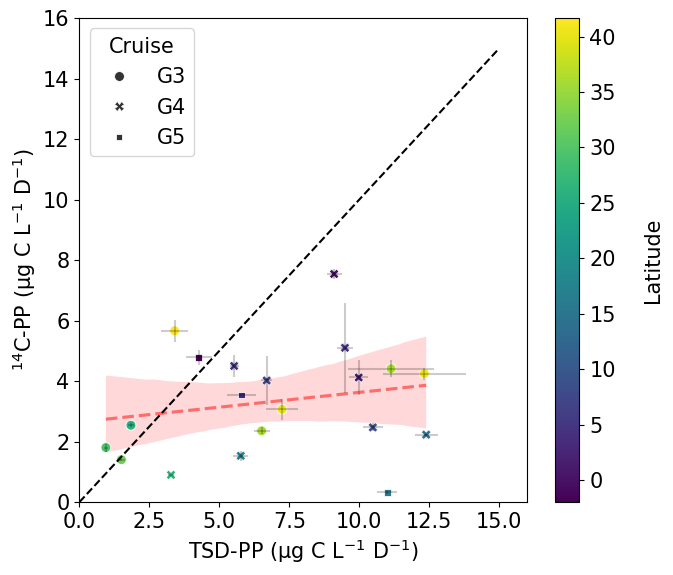

In [9]:
from scipy import stats
# combine G3-5 data
gradients_merged = pd.concat([g3_merged, g4_merged, g5_merged]).reset_index(drop = True)
# plot
fig, axs = plt.subplots(figsize = (7,6))
x = gradients_merged['productivity_mean_total']
xerr = gradients_merged['productivity_se_total']
y = gradients_merged['0.2-2.0 mm']
yerr = gradients_merged['se']
# plot both
axs.errorbar(x, y, xerr=xerr, yerr=yerr, linestyle = '', alpha = 0.2, ecolor='k')
# plot line of best fit
sns.regplot(x=x, y=y, ax=axs,
            scatter_kws={'s': 10}, line_kws={'linestyle': '--', 
                                             'color': 'red',
                                             'alpha': 0.5})
# scatterplot
custom_grayscale = ['black', 'gray', 'lightgray']
# palette = sns.color_palette(custom_grayscale),
color_col = 'Latitude'
norm = plt.Normalize(gradients_merged[color_col].min(), gradients_merged[color_col].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
# plot data
g = sns.scatterplot(gradients_merged, x = 'productivity_mean_total',
                y = '0.2-2.0 mm', hue = color_col, palette='viridis',
                style = 'cruise', s = 50
)
## legend
# make colorbar for hue
cbar = axs.figure.colorbar(sm, ax=axs)
cbar.set_label(color_col, rotation=90, labelpad=20) 
# remove hue in normal legend
hand, labl = axs.get_legend_handles_labels()
handout=[]
lablout=[]
for h,l in zip(hand,labl):
    if l in ['G3', 'G4', 'G5']:
        lablout.append(l)
        handout.append(h)
axs.legend(handout, lablout, title = 'Cruise')
# plot 1:1
onex = np.linspace(0, 15, 100)
axs.plot(onex, onex, linestyle = '--', c = 'k')
## plot line of best fit
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# calculate best fit
yfit = (slope * onex) + intercept
# axs.plot(onex, yfit, linestyle = '--', c = 'k')
axs.set_xlabel('TSD-PP (µg C $\mathregular{L^{-1}}$ $\mathregular{D^{-1}}$)')
axs.set_ylabel('$\mathregular{^{14}C}$-PP (µg C $\mathregular{L^{-1}}$ $\mathregular{D^{-1}}$)')
axs.set_xlim((0, 16))
axs.set_ylim((0, 16))
# aesthetics
plt.rcParams.update({'font.size':15})
plt.tight_layout()
plt.show()

### Statistics

#### are TSD- and 14C-PP significantly different between G3-5? 

In [10]:
# concat all size-fractionated rates
sf_cruises = [g3_sf, g4_sf, g5_sf]
all_sizef = pd.concat(sf_cruises)
all_sizef['round_lat'] = 2 * round(all_sizef['Latitude']/ 2)
sf_PP = all_sizef['0.2-2.0 mm'].values
# get all TSD rates
gradients_cruises = [g3_tsd_total, g4_tsd_total, g5_tsd_total]
all_gradients = pd.concat(gradients_cruises)
tsd_PP = all_gradients['productivity_mean_total'].values

## significance test across ALL cruises
from scipy.stats import mannwhitneyu
u_statistic, p_value = mannwhitneyu(sf_PP, tsd_PP, alternative='two-sided')

# Print the results
print(f"Mann-Whitney U statistic: {u_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the null hypothesis. There is a significant difference between the two groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference between the two groups.")

## significance test for each cruise
names = ['G3', 'G4', 'G5']
counter = 0
for sf_cruise, tsd_cruise in zip(sf_cruises, gradients_cruises):
    print(names[counter])
    # get PP results 
    sf_PP = sf_cruise['0.2-2.0 mm'].values
    tsd_PP = tsd_cruise['productivity_mean_total'].values
    # run test
    u_statistic, p_value = mannwhitneyu(sf_PP, tsd_PP, alternative='two-sided')

    # Print the results
    print(f"Mann-Whitney U statistic: {u_statistic}")
    print(f"P-value: {p_value}")

    # Interpret the results
    alpha = 0.05
    if p_value < alpha:
        print("Conclusion: Reject the null hypothesis. There is a significant difference between the two groups.")
    else:
        print("Conclusion: Fail to reject the null hypothesis. There is no significant difference between the two groups.")
    counter += 1

Mann-Whitney U statistic: 299.0
P-value: 3.285695155190514e-06
Conclusion: Reject the null hypothesis. There is a significant difference between the two groups.
G3
Mann-Whitney U statistic: 57.0
P-value: 0.2356799134290376
Conclusion: Fail to reject the null hypothesis. There is no significant difference between the two groups.
G4
Mann-Whitney U statistic: 49.0
P-value: 0.018043592782942677
Conclusion: Reject the null hypothesis. There is a significant difference between the two groups.
G5
Mann-Whitney U statistic: 6.0
P-value: 0.0002948547840188707
Conclusion: Reject the null hypothesis. There is a significant difference between the two groups.


#### What are the means of each method?

In [10]:
# How different are TSD and 14C-PP? 
np.mean(all_gradients['productivity_mean_total'])
np.std(all_gradients['productivity_mean_total']) / np.sqrt(len(all_gradients))
np.mean(all_sizef['0.2-2.0 mm'])
np.std(all_sizef['0.2-2.0 mm']) / np.sqrt(len(all_sizef))

0.29196438537310204

### Figure 6B, C
- Percent difference between 14C- and TSD-PP across latitude
- Prochlorococcus TSD-PP across latitude

In [15]:
# helper function for propagating standard error across am ean
def propagate_se_mean(se_values):
    # propagate SE for unweighted mean
    se_clean = se_values.dropna()
    n = len(se_clean)
    if n == 0:
        return np.nan
    return np.sqrt((se_clean**2).sum()) / n

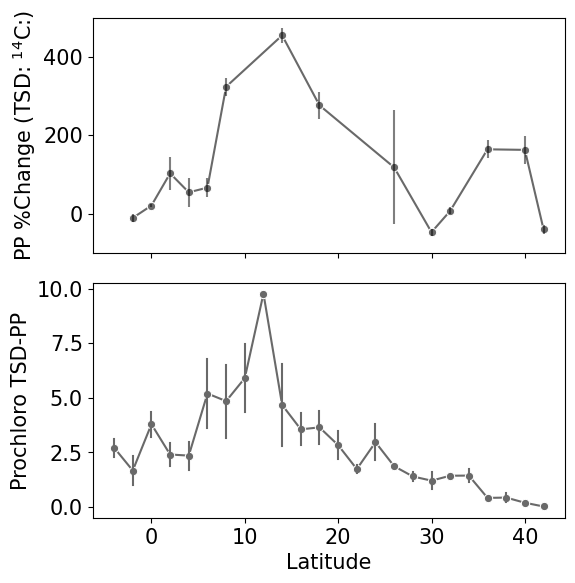

In [19]:
# plot the percent differecne over Latitude
### use percent change with 14C as the base 
gradients_merged['percent_diff'] = ((gradients_merged['productivity_mean_total'] - gradients_merged['0.2-2.0 mm']) / 
                                    (gradients_merged['0.2-2.0 mm']))  * 100
# calc error prop for %diff SE 
A = gradients_merged['productivity_mean_total']
B = gradients_merged['0.2-2.0 mm']
sigma_A = gradients_merged['productivity_se_total']
sigma_B = gradients_merged['se']

D = A - B
sigma_D = np.sqrt(sigma_A**2 + sigma_B**2)

# SE of percent difference
#se_pd = (sigma_D / np.abs(B)) * 100  # absolute error approach, robust near PD ≈ 0

# Or equivalently using the full ratio propagation:
PD = (D / B) * 100
se_pd = np.abs(PD) * np.sqrt((sigma_D / D)**2 + (sigma_B / B)**2)

gradients_merged['percent_diff_se'] = se_pd

# drop the one outlier
gradients_sub = gradients_merged.loc[gradients_merged['percent_diff'] < 1000]
# round by lat
gradients_sub['round_lat'] = 2 * round(gradients_sub['Latitude']/ 2)
# define threshold
gradients_sub.loc[gradients_sub['percent_diff'] >= 50, 'threshold'] = 'Above 50%'
gradients_sub.loc[gradients_sub['percent_diff'] < 50, 'threshold'] = 'Below 50%'
# calculate binned data
binned_df = pd.DataFrame({
    'percent_diff_mean': gradients_sub.groupby('round_lat')['percent_diff'].mean(),
    'percent_diff_sem': gradients_sub.groupby('round_lat')['percent_diff'].sem() ** 2,
    'percent_diff_se':   gradients_sub.groupby('round_lat')['percent_diff_se'].apply(propagate_se_mean) ** 2,
    'n':                 gradients_sub.groupby('round_lat')['percent_diff'].count()
})
binned_df.reset_index(inplace=True)
# combine propagated errors (ignore nan)
binned_df['total_se'] = np.sqrt(binned_df[['percent_diff_sem','percent_diff_se']].sum(axis=1,min_count=1))
#### PLOT ####
fig, axs = plt.subplots(nrows = 2, sharex=True, figsize = (6,6))
x = gradients_sub['round_lat']
y = gradients_sub['percent_diff']
# plot error bars
# plot the percent difference
x = binned_df['round_lat']
y = binned_df['percent_diff_mean']
yerr = binned_df['total_se']
sns.lineplot(gradients_sub, x='round_lat', y='percent_diff', marker = 'o', ax=axs[0], estimator = 'mean', errorbar = None, color = 'dimgray')
axs[0].errorbar(x, y, yerr=yerr, linestyle = '', alpha = 0.5, ecolor='k')
# x labels
axs[0].set_ylabel(r"PP %Change (TSD: $^{14}$C:)")
axs[0].set_ylim(-100, 500)

cruises = ['KM1906', 'TN397', 'TN412']
# plot Pro productivity
pro_sub = good_rates.loc[(good_rates['pop'] == 'prochloro') & (good_rates['cruise'].isin(cruises))]
# bin by every 2º
pro_sub['round_lat'] = 2 * (round(pro_sub['lat'] / 2))
# plot over lat
sns.lineplot(pro_sub, x = 'round_lat', y = 'productivity', ax=axs[1], marker = 'o', err_style='bars', errorbar = 'se',  color = 'dimgray')
axs[1].set_ylabel("Prochloro TSD-PP")
axs[1].set_xlabel("Latitude")


plt.rcParams.update({'font.size': 15})
plt.tight_layout()
plt.show()

### Fig S7
- Total TSD-PP, group-specific TSD-PP, and 0.2-2µm size fractionated TSD-PP across latitude in 2º bins

Text(0, 0.5, 'PP (µg C $\\mathregular{L^{-1}}$ $\\mathregular{D^{-1}}$)')

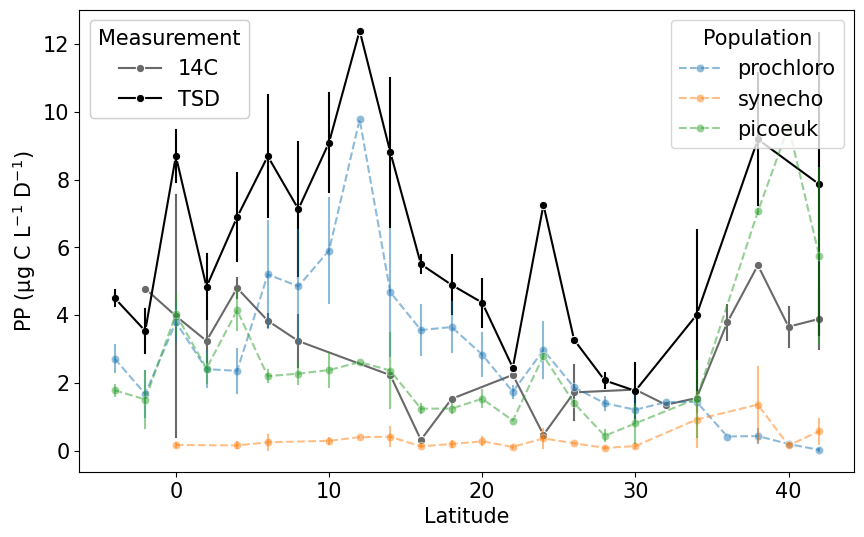

In [18]:
fig, axs = plt.subplots(figsize = (10, 6))
# 14C-PP (SF)
l1 = sns.lineplot(all_sizef, x = 'round_lat', y = '0.2-2.0 mm', marker = 'o', err_style='bars', errorbar = 'se',  c = 'dimgray', ax = axs, label = '14C')
# plot TSD-PP
l2 = sns.lineplot(all_gradients, x = 'round_lat', y = 'productivity_mean_total', marker = 'o', err_style='bars', errorbar = 'se',  c = 'k', ax = axs, label = 'TSD')


# plot population TSD-PP
tsd_long = pd.concat([g3_TSD, g4_TSD, g5_TSD])
tsd_long['round_lat'] = 2 * round(tsd_long['lat'] / 2)
l3 = sns.lineplot(tsd_long, x = 'round_lat', y = 'productivity', hue = 'pop', alpha = 0.5, marker = 'o', errorbar = 'se', err_style = 'bars',linestyle = '--')
h, l = axs.get_legend_handles_labels()
# make first legend for mehod
legend1 = axs.legend(h[:2], l[:2], loc='upper left', title='Measurement')
axs.add_artist(legend1)
# make second legend for population
legend2 = axs.legend(h[2:], l[2:], loc='upper right', title='Population')
axs.add_artist(legend1)
# aesthetics
axs.set_xlabel("Latitude")
axs.set_ylabel("PP (µg C $\mathregular{L^{-1}}$ $\mathregular{D^{-1}}$)")

### Small phytoplankton contributions to community PP on Gradients transects

### Read in G1-5 data

In [ ]:
### pull data from Simons CMAP ###
from dotenv import load_dotenv
import os
import pycmap
# grab API key from hidden file
load_dotenv()
api_key = os.getenv("API_KEY")  
# load api key from CMAP
api = pycmap.API(token=api_key)

# only G1, G2, and G4 data on CMAP
tbls=['tblKOK1606_Gradients1_14C_NPP',
      'tblMGL1704_Gradients2_14C_NPP',
      'tblGradients4_TN397_14C_NPP_DailyOnDeck']
# read in data
NPP_dfs=[]
bin = 2
for tbl in tbls:
    print(tbl)
    # get dataset and add data info
    df = api.get_dataset(tbl)
    df['dataset']=tbl
    # clean up time
    df['exact_time'] = pd.DatetimeIndex(df['time']).tz_localize('UTC')
    # add day
    df['time'] = df['exact_time'].dt.round('1d')
    # round latitudes
    df['round_lat'] = bin * round(df['lat'] / bin)
    df['pop'] = 'community'
    NPP_dfs.append(df)

# create df for each cruise 14C PP data
g1_NPP = NPP_dfs[0]
g2_NPP = NPP_dfs[1]
g3_NPP = g3_sf.copy()
g3_NPP['round_lat'] = bin * round(g3_NPP['Latitude'] / bin)
g3_NPP['pop'] = 'community'
g4_NPP = NPP_dfs[2]
g5_NPP = pd.read_csv('../data/g5_gff.csv')
g5_NPP['round_lat'] = bin * round(g5_NPP['Latitude'] / bin)
g5_NPP['pop'] = 'community'

# redefine NPP_dfs
NPP_dfs = [g1_NPP, g2_NPP, g3_NPP, g4_NPP, g5_NPP]

tblKOK1606_Gradients1_14C_NPP
tblMGL1704_Gradients2_14C_NPP
tblGradients4_TN397_14C_NPP_DailyOnDeck


### Calculate significance test with community 14C- vs TSD-PP

In [121]:
## clean 14C community data
gradients_names = ['KOK1606','MGL1704','KM1906','TN397', 'TN412']
# this is in mg/m3 for each day = µg/L/D
cfix_cols = ['PP_24L_D', 'LminusD_24', 'GFF mean', 'Cfix', 'Mean']
cfix_std_cols = ['PP_24L_D_stdev_p', 'stdev_24', 'stdev', 'stdev_Cfix', 'stdev']

# update col name for consistency
subset_dfs = []
for df, cruise, cfix_col, sd_col in zip(NPP_dfs, gradients_names, cfix_cols, cfix_std_cols):
    df['cruise'] = cruise
    df.rename(columns = {cfix_col: 'comm_productivity',
                         sd_col: 'comm_sd'}, inplace = True)
    subset_dfs.append(df[['cruise', 'round_lat', 'pop', 'comm_productivity', 'comm_sd']])

comm_df = pd.concat(subset_dfs)
# calc variance
comm_df['comm_var'] = comm_df['comm_sd'] ** 2

### error propagation for variances to calc sd 
# Inverse-variance weights
comm_df['weight'] = 1.0 / comm_df['comm_var']
comm_df['weighted_mean'] = comm_df['weight'] * comm_df['comm_productivity']

# Aggregate within each bin
binned = (
    comm_df
    .groupby(['round_lat', 'pop'])
    .agg(
        n=('weighted_mean', 'size'),
        binned_mean=('weighted_mean', 'sum'),
        weight_sum=('weight', 'sum')
    )
    .reset_index()
)
# Inverse-variance weighted mean and its propagated variance
binned['comm_productivity'] = binned['binned_mean'] / binned['weight_sum']
binned['comm_var'] = 1.0 / binned['weight_sum']
binned['comm_sd'] = np.sqrt(binned['comm_var'])
# subset 
binned = binned[['round_lat', 'pop', 'comm_productivity', 'comm_var', 'comm_sd']]

In [128]:
## clean TSD-PP
# change lat bin to 2º
good_rates['round_lat'] = bin * round(good_rates['lat'] / bin)
# get means for all gradients cruises
gradients_all = good_rates.loc[good_rates['cruise'].isin(gradients_names)]

## plot SF productivity
mean_gradients = gradients_all.groupby(['round_lat', 'pop']).agg({
    'productivity':['mean', 'var']
})
mean_gradients.columns = ['_'.join(col).strip() for col in mean_gradients.columns.values]
mean_gradients.reset_index(inplace=True)
# get sums of mean population totals
sum_gradients = mean_gradients.groupby(['round_lat']).sum().reset_index()

tsd_df = sum_gradients.rename(columns = {'productivity_mean': 'sf_productivity',
                                         'productivity_var': 'sf_var'})
# calc sd
tsd_df['sf_sd'] = np.sqrt(tsd_df['sf_var'])

# merge TSD and Comm dfs
tsd_comm_df = tsd_df.merge(binned)
tsd_comm_df['rel_contribution'] = (tsd_comm_df['sf_productivity'] / tsd_comm_df['comm_productivity']) * 100

In [144]:
## check for significance using a z-test
from scipy.stats import norm
# previously generated with standard deviations from each measurements
# data = pd.read_csv("~/Downloads/sf_comm_productivity.csv")
data = tsd_comm_df.copy()
results = []

for _, row in data.iterrows():
    sf = row['sf_productivity']
    comm = row['comm_productivity']
    sf_sd = row['sf_sd']
    comm_sd = row['comm_sd']
    
    if pd.notna(sf_sd) and pd.notna(comm_sd) and sf_sd > 0 and comm_sd > 0:
        z = (sf - comm) / np.sqrt(sf_sd**2 + comm_sd**2)
        p = 2 * (1 - norm.cdf(abs(z)))
        significant = 'Yes' if p < 0.05 else 'No'
    else:
        z, p, significant = np.nan, np.nan, 'No'
    results.append({
        'round_lat': row['round_lat'],
        'z_stat': z,
        'p_value': p,
        'significant': significant
    })

ztest_results = pd.DataFrame(results)
data['rel_contribution'] = (data['sf_productivity'] / data['comm_productivity']) * 100

### Figure 6B
- Small Phytoplankton TSD-PP vs. Bulk 14C Measurements across N. Pacific

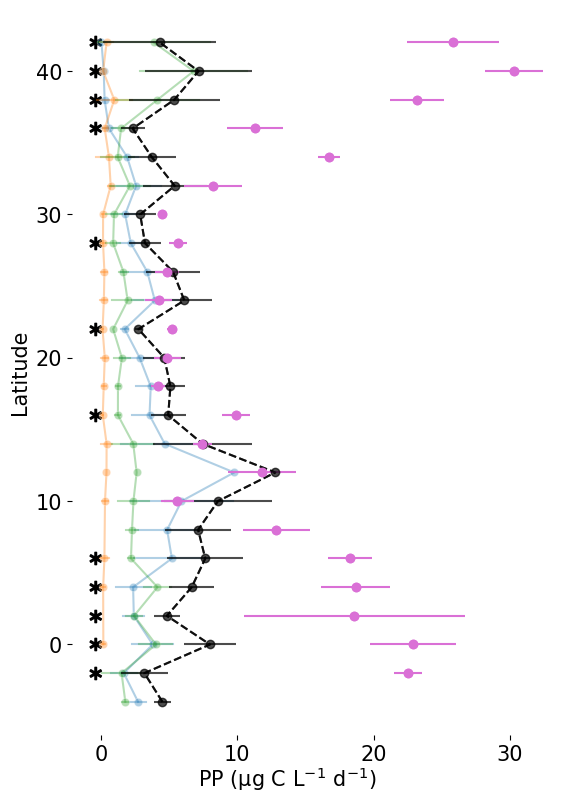

In [145]:
# Plot total picoplankton biomass per lat
fig,axs=plt.subplots(figsize=(6,8))
# make vertical lineplot for each cruise
nums=[1,2,3,4,5]
counter=0
gradients_names = ['KOK1606','MGL1704','KM1906','TN397', 'TN412']
# this is in mg/m3 for each day = µg/L/D
cfix = 'comm_productivity'
cfix_std = 'comm_sd'
## plot mean population productivity, mean 0.2-2µm SF productivity, and mean community productivity by latitude

# plot population productivity
g=sns.lineplot(gradients_all, x='productivity', y ='round_lat',
                ax=axs, hue='pop', orient='y', estimator='mean',legend=False,
                errorbar='sd', err_style='bars',alpha=0.35, marker='o')
g.set(xlabel=None)

axs.plot(sum_gradients['productivity_mean'], sum_gradients['round_lat'], color='k', linestyle = '--', alpha=0.8,)
axs.errorbar(sum_gradients['productivity_mean'], sum_gradients['round_lat'], xerr=np.sqrt(sum_gradients['productivity_var']),
             color='k', linestyle = '--', alpha=0.7, marker ='o')
## add a star to latitudes with significant differences
# get latitudes where significant difference was found
sig_lats = ztest_results.loc[ztest_results['significant']=='Yes', 'round_lat']
sig_gradients = sum_gradients.loc[sum_gradients['round_lat'].isin(sig_lats)]
y_star = np.tile(-0.5, len(sig_gradients['productivity_mean']))
# plot stars at x=0 where significantly different
axs.scatter(y_star, sig_gradients['round_lat'], marker=r'$\ast$', color='k', s=100)
## summarize 14C community data
g_NPP_dfs = [g1_NPP, g2_NPP, g3_NPP, g4_NPP, g5_NPP]
cfix_clean = []
for cruise, NPP_df in zip(gradients_names, g_NPP_dfs):
    if NPP_df is not None: 
        # round latitudes to 2º based on column name
        if 'lat' in NPP_df.columns:
            NPP_df['round_lat']=2 * round(NPP_df['lat']/2)
        else:
            NPP_df['round_lat']=2 * round(NPP_df['Latitude']/2)
        # calculate rounded productivity and SD for cruises with sd cols
        if cfix_std is not None:
            NPP_df['var'] = NPP_df[cfix_std] ** 2
            round_NPP = NPP_df.groupby(['round_lat']).agg({
                cfix:'mean',
                'var': 'sum'
            }).reset_index()
            round_NPP=NPP_df.sort_values(by='round_lat')
        # cruises without sd cols
        else:
            round_NPP = NPP_df.groupby(['round_lat']).agg({
                cfix:['mean', 'var']
            })
            round_NPP.columns = ['_'.join(col).strip() for col in round_NPP.columns.values]
            round_NPP.reset_index(inplace=True)
            round_NPP=round_NPP.sort_values(by='round_lat')
    # reset column names
    round_NPP.rename(columns = {cfix:'mean_productivity'}, inplace=True)
    # add cruise name
    cfix_clean.append(round_NPP[['round_lat', 'mean_productivity', 'var']])
# concatnate community data
all_cfix = pd.concat(cfix_clean)
# calculate mean and std per lat
mean_cfix = all_cfix.groupby(['round_lat']).agg({
    'mean_productivity':'mean',
    'var':'sum'
}).reset_index()
# plot community productivity and errors
ln1=axs.plot(mean_cfix['mean_productivity'], mean_cfix['round_lat'], color='orchid', alpha=0.8, 
            label='Total Community', marker='o', linestyle = '')
axs.errorbar(mean_cfix['mean_productivity'], mean_cfix['round_lat'], xerr=np.sqrt(mean_cfix['var']), fmt='o', color='orchid')

# set labels
axs.set_ylabel('Latitude')
fig.text(0.5, 0.000001, 'PP (µg C $\mathregular{L^{-1}}$ $\mathregular{d^{-1}})$',
         ha='center', c= 'k')

# set label

# aesthetics
sns.despine(left=True, bottom=True)
plt.rcParams.update({'font.size':15})
plt.tight_layout()
plt.show()